In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [2]:
df_ny_raw = pd.read_csv("data/raw/foursquare_complete_ny.csv")

df_ny = df_ny_raw.dropna(subset=["venue_category_ID", "timezone"])
#rename lon to lng and venue_id to venueID
df_ny.rename(columns={"lon": "lng", "venue_id": "venueID", 'utc_time':'time', 'venue_category_name':'venue_descr'}, inplace=True)
#reorder columns
df_ny = df_ny[['uid',  'lat', 'lng', 'venueID', 'venue_descr', 'time', 'venue_category_id']]

df_ny["venueID"] = df_ny["venueID"].astype(str)

df_ny["time"] = pd.to_datetime(df_ny["time"])
df_ny["city_name"] = "New York City"

df_ny.head()

/tmp/ipykernel_3304172/2559800773.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ny["time"] = pd.to_datetime(df_ny["time"])


,uid,lat,lng,venueID,venue_descr,time,venue_category_id,city_name
0,1,40.717888,-74.005668,33236,Mexican Restaurant,2012-04-13 15:41:41+00:00,4bf58dd8d48988d1c1941735,New York City
1,1,40.733763,-74.006264,791,Diner,2012-04-20 01:49:26+00:00,4bf58dd8d48988d147941735,New York City
2,1,40.645089,-73.784523,1511,Airport,2012-08-10 16:40:07+00:00,4bf58dd8d48988d1ed931735,New York City
3,1,40.640856,-73.789201,6720,Steakhouse,2012-08-10 17:05:07+00:00,4bf58dd8d48988d1cc941735,New York City
4,1,40.734895,-74.003155,255,Seafood Restaurant,2012-12-14 17:55:32+00:00,4bf58dd8d48988d1ce941735,New York City


In [3]:
df_tky_raw = pd.read_csv("data/raw/dataset_TSMC2014_TKY.txt", sep="\t", header=None, encoding='latin1')

df_tky_raw.columns = ["uid", "venue_id", "venue_category_id", "venue_category_name", "lat", "lon", "timezone", "utc_time"]


df_tky = df_tky_raw.dropna(subset=["venue_category_id", "timezone"])
#rename lon to lng and venue_id to venueID
df_tky.rename(columns={"lon": "lng", "venue_id": "venueID", 'utc_time':'time', 'venue_category_name':'venue_descr'}, inplace=True)
#reorder columns
df_tky = df_tky[['uid',  'lat', 'lng', 'venueID', 'venue_descr', 'time', 'venue_category_id']]

df_tky["venueID"] = df_tky["venueID"].astype(str)

df_tky["time"] = pd.to_datetime(df_tky["time"])
df_tky["city_name"] = "Tokyo"

df_tky.head()

/tmp/ipykernel_3304172/2076743810.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_tky["time"] = pd.to_datetime(df_tky["time"])


,uid,lat,lng,venueID,venue_descr,time,venue_category_id,city_name
0,1541,35.705101,139.619590,4f0fd5a8e4b03856eeb6c8cb,Cosmetics Shop,2012-04-03 18:17:18+00:00,4bf58dd8d48988d10c951735,Tokyo
1,868,35.715581,139.800317,4b7b884ff964a5207d662fe3,Ramen / Noodle House,2012-04-03 18:22:04+00:00,4bf58dd8d48988d1d1941735,Tokyo
2,114,35.714542,139.480065,4c16fdda96040f477cc473a5,Convenience Store,2012-04-03 19:12:07+00:00,4d954b0ea243a5684a65b473,Tokyo
3,868,35.725592,139.776633,4c178638c2dfc928651ea869,Food & Drink Shop,2012-04-03 19:12:13+00:00,4bf58dd8d48988d118951735,Tokyo
4,1458,35.656083,139.734045,4f568309e4b071452e447afe,Housing Development,2012-04-03 19:18:23+00:00,4f2a210c4b9023bd5841ed28,Tokyo


In [7]:
df_tky_raw["uid"].nunique(), df_tky_raw["venue_id"].nunique(), len(df_tky_raw)

(2293, 61858, 573703)

In [10]:
df_ny_raw["uid"].nunique(), df_ny_raw["venue_id"].nunique(), len(df_ny_raw)

(1083, 38333, 227428)

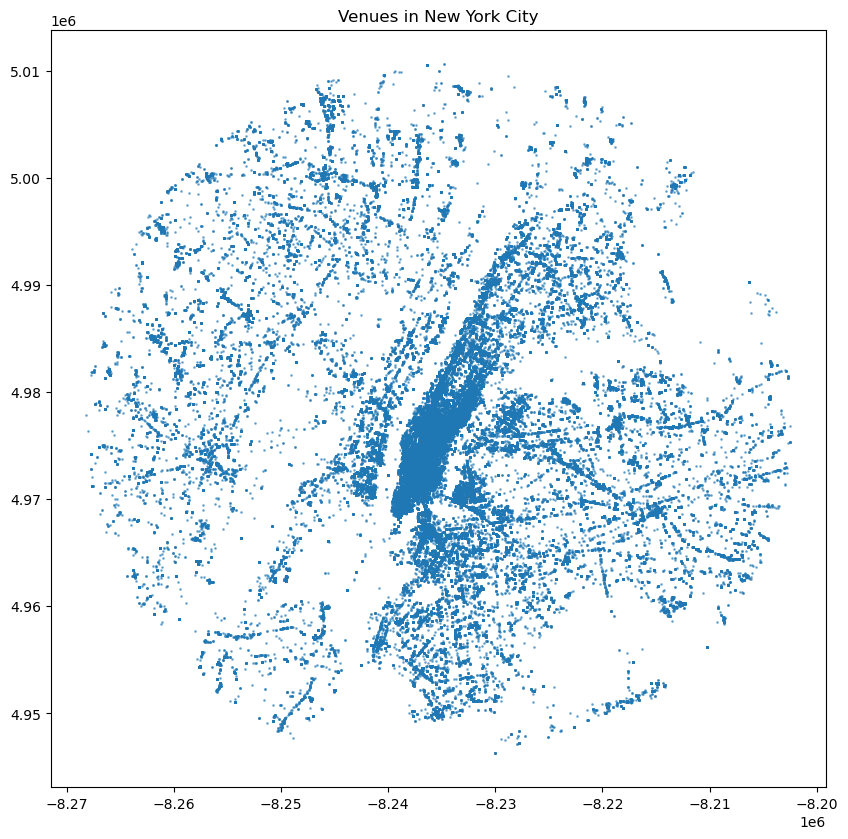

In [6]:
#plot the heatmap of the venues in New York City
gdf_ny = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny.lng, df_ny.lat))
gdf_ny.crs = "EPSG:4326"
gdf_ny = gdf_ny.to_crs("EPSG:3857") 
gdf_ny.plot(figsize=(10, 10), alpha=0.5, markersize=1)
plt.title("Venues in New York City")
plt.show()


In [8]:
#calculate the area of the bounding box of the venues in New York City
bbox_ny = gdf_ny.total_bounds
area_ny = (bbox_ny[2] - bbox_ny[0]) * (bbox_ny[3] - bbox_ny[1])
print(f"Area of the bounding box of the venues in New York City: {area_ny:.2f} square meters")


Area of the bounding box of the venues in New York City: 4230141771.36 square meters


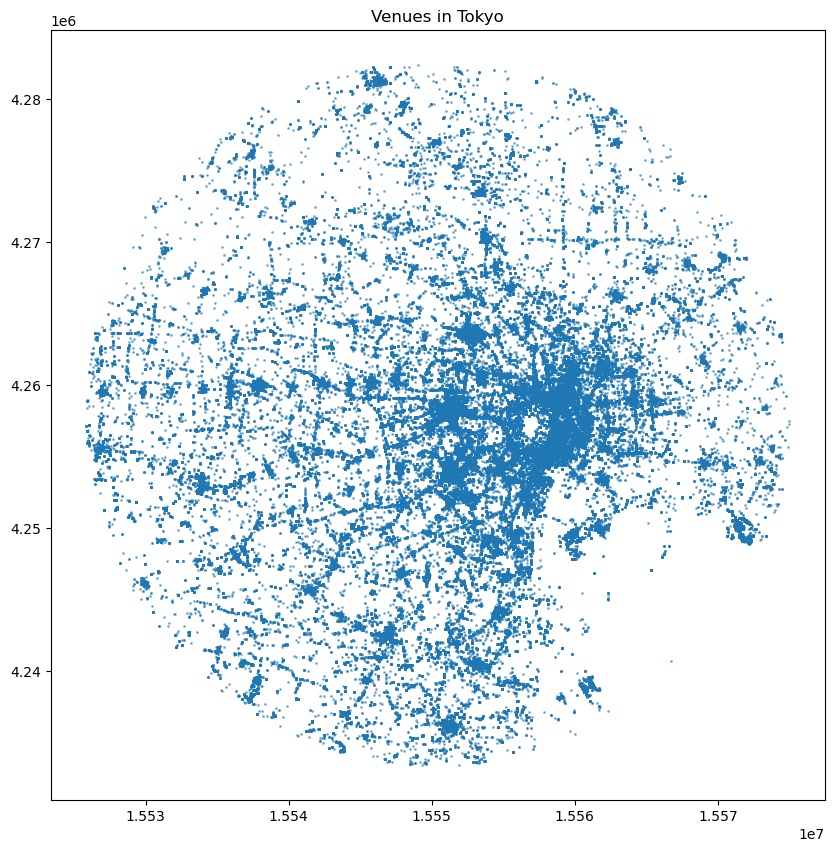

In [9]:
##plot the heatmap of the venues in Tokyo
gdf_tky = gpd.GeoDataFrame(df_tky, geometry=gpd.points_from_xy(df_tky.lng, df_tky.lat))
gdf_tky.crs = "EPSG:4326"
gdf_tky = gdf_tky.to_crs("EPSG:3857")
gdf_tky.plot(figsize=(10, 10), alpha=0.5, markersize=1)
plt.title("Venues in Tokyo")
plt.show()



In [10]:
#calculate the area of the bounding box of the venues in Tokyo
bbox_tky = gdf_tky.total_bounds
area_tky = (bbox_tky[2] - bbox_tky[0]) * (bbox_tky[3] - bbox_tky[1])
print(f"Area of the bounding box of the venues in Tokyo: {area_tky:.2f} square meters")


Area of the bounding box of the venues in Tokyo: 2405750970.17 square meters


In [11]:
area_tky / area_ny

0.5687163930207368

In [19]:
print(df_tky_raw["uid"].nunique(), df_ny_raw["uid"].nunique())
print(df_tky_raw["uid"].nunique() / df_ny_raw["uid"].nunique())

2293 1083
2.1172668513388735


In [13]:
df_ny["uid"].nunique(), df_tky["uid"].nunique()

(1083, 2293)

In [17]:
print(df_tky_raw["venue_id"].nunique(), df_ny_raw["venue_id"].nunique())
print(df_tky_raw["venue_id"].nunique() / df_ny_raw["venue_id"].nunique())


61858 38333
1.6137009887042495


# Cleaned Tokyo dataset properties

In [14]:
import pandas as pd
tky_sample = pd.read_csv("data/processed/foursquare_complete_tky_cp_full_sampled.csv")

tky_sample["uid"].nunique(), tky_sample["venueID"].nunique(), len(tky_sample)

(1083, 34314, 141968)